<a href="https://colab.research.google.com/github/ColinBorel/scikit-learn-mooc/blob/main/quizzes/Wrap_up_quiz_Ensemble_Method_to_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wrap-up quiz - Ensemble Method

**This quiz requires some programming to be answered.**

This wrap-up quiz uses the penguins dataset, but notice that **we do not use the
traditional `Species` column** as predictive target:

```python
import pandas as pd

dataset = pd.read_csv("https://raw.githubusercontent.com/bilals/scikit-learn-mooc/main/datasets/penguins.csv")

feature_names = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
]
target_name = "Body Mass (g)"

dataset = dataset[feature_names + [target_name]].dropna(axis="rows", how="any")
dataset = dataset.sample(frac=1, random_state=0).reset_index(drop=True)
data, target = dataset[feature_names], dataset[target_name]
```

We therefore define our problem as a regression problem: we want to predict the
body mass of a penguin given its culmen and flipper measurements.

Notice that we randomly shuffled the rows of the dataset after loading it
(`dataset.sample(frac=1, random_state=0)`). The reason is to break a spurious
order-related statistical dependency that would otherwise cause trouble with the
naive cross-validation procedure we use in this notebook. The problem of
order-dependent samples will be discussed more in detail on the model evaluation
module and is outside of the scope of this quiz for now.
Now, evaluate the following tree-based models:

- a decision tree regressor, i.e. `sklearn.tree.DecisionTreeRegressor`
- a random forest regressor, i.e. `sklearn.ensemble.RandomForestRegressor`

Use the default hyper-parameter settings for both models. The only exception
is to pass `random_state=0` for all models to be sure to recover the exact
same performance scores as the solutions to this quiz.

Evaluate the generalization performance of these models using a 10-fold
cross-validation:

- use `sklearn.model_selection.cross_validate` to run the cross-validation routine
- set the parameter `cv=10` to use a 10-fold cross-validation strategy. Store the
training score of the cross-validation by setting the parameter
`return_train_score=True` in the function `cross_validate`
as we will use it later on.

## Question 1
```
By comparing the cross-validation test scores fold-to-fold, count the number of times
a random forest is better than a single decision tree.
Select the range which this number belongs to:

- a) [0, 3]: the random forest model is substantially worse than the single decision tree regressor
- b) [4, 6]: both models are almost equivalent
- c) [7, 10]: the random forest model is substantially better than the single decision tree regressor

_Select a single answer_
```


Now, train and evaluate with the same cross-validation strategy a random forest
with 5 decision trees and another containing 100 decision trees. Once again
store the training score.

## Question 2
```
By comparing the cross-validation test scores fold-to-fold, count the number of times
a random forest with 100 decision trees is better than a random forest with
5 decision trees.
Select the range which this number belongs to:

- a) [0, 3]: the random forest model with 100 decision trees is substantially worse than the random forest model with 5 decision trees
- b) [4, 6]: both models are almost equivalent
- c) [7, 10]: the random forest model with 100 decision trees is substantially better than the random forest model with 5 decision trees

_Select a single answer_
```

Plot the validation curve of the `n_estimators` parameters defined by:

```python
import numpy as np


n_estimators = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1_000])
```

## Question 3

```
Select the correct statements below.

- a) the **train score** decreases when `n_estimators` become large (above 500 trees)
- b) the **train score** reaches a plateau when `n_estimators` become large (above 500 trees)
- c) the **train score** increases when `n_estimators` become large (above 500 trees)
- d) the **test score** decreases when `n_estimators` become large (above 500 trees)
- e) the **test score** reaches a plateau when `n_estimators` become large (above 500 trees)
- f) the **test score** increases when `n_estimators` become large (above 500 trees)

_Select all answers that apply_
```

Repeat the previous experiment but this time, instead of choosing the default
parameters for the random forest, set the parameter `max_depth=5` and build
the validation curve.

## Question 4
```
Comparing the validation curve (train and test scores) of the random forest
with a full depth and the random forest with a limited depth, select the correct
statements.

- a) the **test score** of the random forest with a full depth is (almost) always better than the **test score** of the random forest with a limited depth
- b) the **train score** of the random forest with a full depth is (almost) always better than the **train score** of the random forest with a limited depth
- c) the gap between the train and test scores decreases when reducing the depth of the trees of the random forest
- d) the gap between the train and test scores increases when reducing the depth of the trees of the random forest


_Select all answers that apply_
```


Let us now focus at the very beginning of the validation curves, and
consider the training score of a random forests with a single tree
while using the default `max_depth=None` parameter setting:

```python
rf_1_tree = RandomForestRegressor(n_estimators=1, random_state=0)
cv_results_tree = cross_validate(
    rf_1_tree, data, target, cv=10, return_train_score=True
)
cv_results_tree["train_score"]
```

should return:

```
array([0.83120264, 0.83309064, 0.83195043, 0.84834224, 0.85790323,
       0.86235297, 0.84791111, 0.85183089, 0.82241954, 0.85045978])

```

The fact that this single-tree Random Forest can never reach
a perfect R2 score of 1.0 on the training can be surprising.

Indeed, if you we evaluate the training accuracy of the single
`DecisionTreeRegressor` one gets perfect memorization of the
training data:

```python
tree = DecisionTreeRegressor(random_state=0)
cv_results_tree = cross_validate(
    tree, data, target, cv=10, return_train_score=True
)
cv_results_tree["train_score"]
```

which outputs the expected perfect score:

```
array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
```

## Question 5
```
From the following statements, select the one that explains
that a single-tree random forest cannot achieve perfect
training scores.

- a) the single tree in the random forest is trained using a bootstrap of the training set and not the training set itself (because `bootstrap=True` by default)
- b) for a given feature, the single tree in the random forest uses random splits while the single decision tree uses the best split
- c) the random forest automatically limits the depth of the single decision tree, which prevents overfitting

_Select a single answer_
```

Build a validation curve for a `sklearn.ensemble.HistGradientBoostingRegressor`
varying `max_iter` as follows:

```python
max_iters = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
```

We recall that `max_iter` corresponds to the number of trees in the boosted
model.

Plot the average train and test score for each value of `max_iter`.

## Question 6
```
Select the correct statements.

- a) for a small number of trees (between 5 and 10 trees), the gradient boosting model behave like the random forest algorithm: the train scores are high while the test scores are not optimum
- b) for a small number of trees (between 5 and 10 trees), the gradient boosting model behave differently to the random forest algorithm: both the train and test scores are small
- c) with a large number of trees (> 100 trees) adding more trees in the ensemble causes the gradient boosting model overfit (increasing the gap between the train score and  test score)
- d) with a large number of trees (> 100 trees) adding more trees in the ensemble does not impact the generalization performance of the gradient boosting model

_Select all answers that apply_
```

In [2]:
import pandas as pd
import sklearn as skl

dataset = pd.read_csv("https://raw.githubusercontent.com/bilals/scikit-learn-mooc/main/datasets/penguins.csv")

feature_names = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
]
target_name = "Body Mass (g)"

dataset = dataset[feature_names + [target_name]].dropna(axis="rows", how="any")
dataset = dataset.sample(frac=1, random_state=0).reset_index(drop=True)
data, target = dataset[feature_names], dataset[target_name]

In [3]:
dt_regressor = skl.tree.DecisionTreeRegressor(random_state=0)
rf_regressor = skl.ensemble.RandomForestRegressor(random_state=0)

cv_dt = skl.model_selection.cross_validate(dt_regressor, data, target, cv=10, return_train_score=True)
cv_rf = skl.model_selection.cross_validate(rf_regressor, data, target, cv=10, return_train_score=True)
# Extract test scores
dt_test_scores = cv_dt['test_score']
rf_test_scores = cv_rf['test_score']
# Count how many times random forest is better than decision tree (higher test score)
count_rf_better = sum(rf_test_scores[i] > dt_test_scores[i] for i in range(10))

print(f"Number of times random forest is better than decision tree: {count_rf_better}")

Number of times random forest is better than decision tree: 10


Question 1 : C


In [5]:
rf_5 = skl.ensemble.RandomForestRegressor(n_estimators=5, random_state=0)
rf_100 = skl.ensemble.RandomForestRegressor(n_estimators=100, random_state=0)

cv_rf5 = skl.model_selection.cross_validate(rf_5, data, target, cv=10, return_train_score=True)
cv_rf100 = skl.model_selection.cross_validate(rf_100, data, target, cv=10, return_train_score=True)

rf5_test_scores = cv_rf5['test_score']
rf100_test_scores = cv_rf100['test_score']

count_rf100_better = sum(rf100_test_scores[i] > rf5_test_scores[i] for i in range(10))
print(f"Number of times random forest with 100 trees is better than random forest with 5 trees: {count_rf100_better}")

Number of times random forest with 100 trees is better than random forest with 5 trees: 9


Question 2 : C

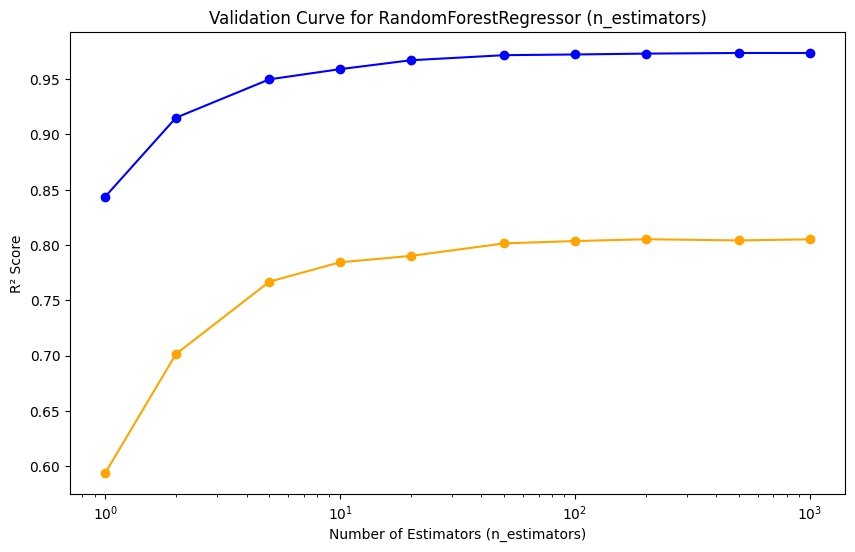

In [11]:
import numpy as np
import matplotlib.pyplot as plt


n_estimators = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1_000])

train_scores, valid_scores = skl.model_selection.validation_curve(
    skl.ensemble.RandomForestRegressor(random_state=0),
    data, target,
    param_name="n_estimators",
    param_range=n_estimators,
    cv=10,
)


train_mean = np.mean(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)


plt.figure(figsize=(10, 6))
plt.plot(n_estimators, train_mean, label="Training Score", color="blue", marker="o")
plt.plot(n_estimators, valid_mean, label="Validation Score", color="orange", marker="o")

# Labels and formatting
plt.xlabel("Number of Estimators (n_estimators)")
plt.ylabel("R² Score")
plt.title("Validation Curve for RandomForestRegressor (n_estimators)")
plt.xscale("log")
plt.show()

Question 3 : B and E

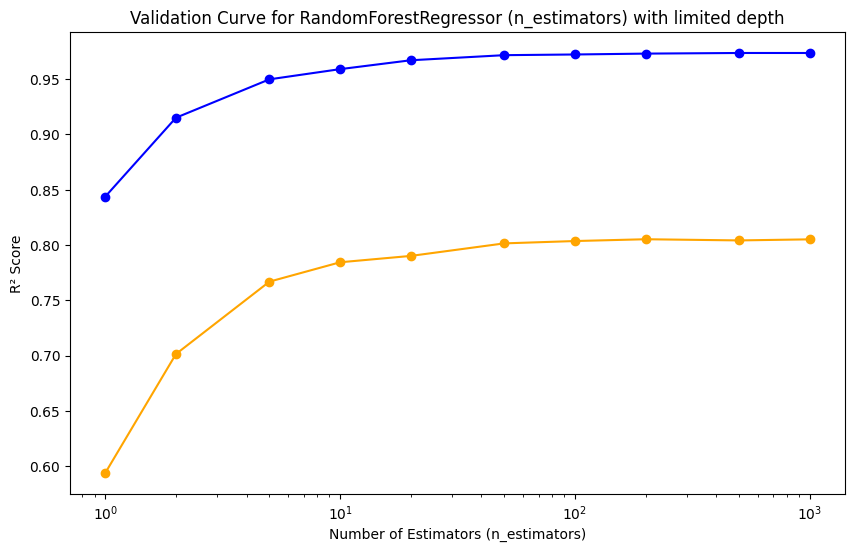

In [12]:

train_scores_limited_depth, valid_scores_limited_depth = skl.model_selection.validation_curve(
    skl.ensemble.RandomForestRegressor(random_state=0, max_depth=5),
    data, target,
    param_name="n_estimators",
    param_range=n_estimators,
    cv=10
)


train_mean_limited_depth = np.mean(train_scores_limited_depth, axis=1)
valid_mean_limited_depth = np.mean(valid_scores_limited_depth, axis=1)


plt.figure(figsize=(10, 6))
plt.plot(n_estimators, train_mean, label="Training Score with limited depth", color="blue", marker="o")
plt.plot(n_estimators, valid_mean, label="Validation Score with limited depth", color="orange", marker="o")

# Labels and formatting
plt.xlabel("Number of Estimators (n_estimators)")
plt.ylabel("R² Score")
plt.title("Validation Curve for RandomForestRegressor (n_estimators) with limited depth")
plt.xscale("log")
plt.show()

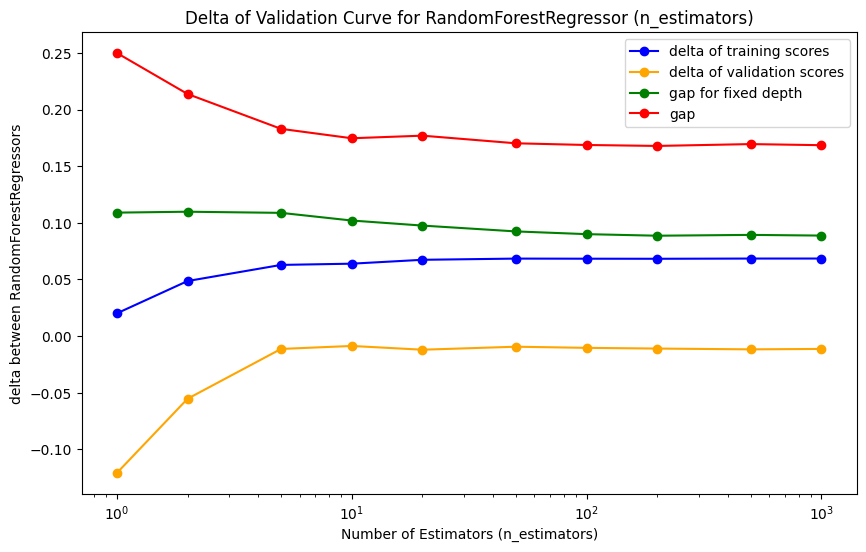

In [16]:
delta_train = train_mean - train_mean_limited_depth
delta_valid = valid_mean - valid_mean_limited_depth
delta_depth = train_mean_limited_depth - valid_mean_limited_depth
delta = train_mean - valid_mean

plt.figure(figsize=(10, 6))
plt.plot(n_estimators, delta_train, label="delta of training scores", color="blue", marker="o")
plt.plot(n_estimators, delta_valid, label="delta of validation scores", color="orange", marker="o")
plt.plot(n_estimators, delta_depth, label="gap for fixed depth", color="green", marker="o")
plt.plot(n_estimators, delta, label="gap", color="red", marker="o")

# Labels and formatting
plt.xlabel("Number of Estimators (n_estimators)")
plt.ylabel("delta between RandomForestRegressors")
plt.title("Delta of Validation Curve for RandomForestRegressor (n_estimators)")
plt.xscale("log")
plt.legend()
plt.show()



Question 4 : B and C

Question 5 : A

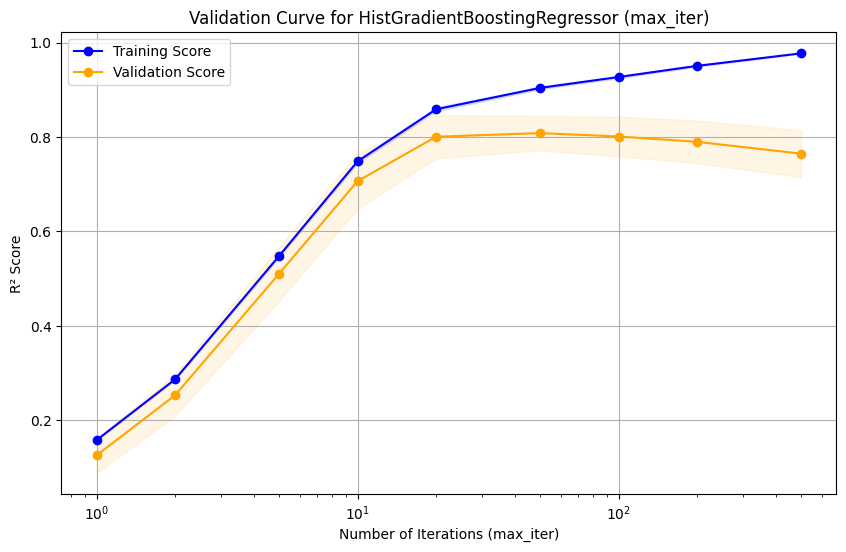

In [18]:
max_iters = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
# Compute the validation curve
train_scores, valid_scores = skl.model_selection.validation_curve(
    skl.ensemble.HistGradientBoostingRegressor(random_state=0),
    data, target,
    param_name="max_iter",
    param_range=max_iters,
    cv=10)


train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

# Plot the validation curve
plt.figure(figsize=(10, 6))
plt.plot(max_iters, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(max_iters, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.plot(max_iters, valid_mean, label="Validation Score", color="orange", marker="o")
plt.fill_between(max_iters, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

# Labels and formatting
plt.xlabel("Number of Iterations (max_iter)")
plt.ylabel("R² Score")
plt.title("Validation Curve for HistGradientBoostingRegressor (max_iter)")
plt.xscale("log")
plt.legend(loc="best")
plt.grid(True)
plt.show()


Question 6 : B and C